In [67]:
import numpy as np
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
(X_train, y_train), (X_test, y_test) = mnist.load_data()
y =  y_train[0]

In [68]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [69]:
print(X_train[0])
print(y_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

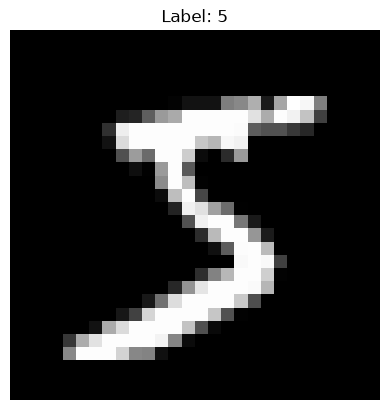

In [70]:

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [71]:
X_train[0].shape

(28, 28)

In [72]:
x = X_train[0].reshape(1, 784) / 255.0

print(x.min())
print(x.max())

0.0
1.0


#LAYER ONE

In [73]:
W1 = np.random.randn(784, 128) * 0.01
b1 = np.zeros((1, 128))



lr = 0.01
Z = x @ W1 + b1
A1 = np.maximum(0, Z)  # ReLU activation
lr = 0.01


##LAYER TWO

In [74]:
W2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))

Z2 = A1 @ W2 + b2

In [75]:
def softmax(z):
    exp_z = np.exp(z - np.max(z))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

probabilities = softmax(Z2)
prediction = np.argmax(probabilities)

correct_probability = probabilities[0, y]
loss = -np.log(correct_probability)
print("Correct digit:", y)
print("Correct probability:", correct_probability)
print("Loss:", loss)

Correct digit: 5
Correct probability: 0.10074262573323592
Loss: 2.2951862745489153


In [76]:
dZ2 = probabilities.copy()
dZ2[0, y] -= 1
dW2 = A1.T @ dZ2
db2 = dZ2
da1 = dZ2 @ W2.T
dz1 = da1 * (Z > 0)  # derivative of ReLU
dW1 = x.T @ dz1
db1 = dz1

In [77]:
W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2
print(W1.shape, b1.shape, W2.shape, b2.shape)

(784, 128) (1, 128) (128, 10) (1, 10)


In [78]:
X = X_train[:32].reshape(32, 784) / 255.0
y = y_train[:32]

print(X.shape)
print(y.shape)

(32, 784)
(32,)


In [79]:
Z1 = X @ W1 + b1
A1 = np.maximum(0, Z1)  # ReLU activation
Z2 = A1 @ W2 + b2
probabilities = softmax(Z2)

In [80]:
correct_probabilities = probabilities[np.arange(32), y]
loss = -np.mean(np.log(correct_probabilities))
print("Loss:", loss)
print("Correct probabilities:", correct_probabilities)  

Loss: 2.3043422452082996
Correct probabilities: [0.10280934 0.10091798 0.10065241 0.09921857 0.09914015 0.09946757
 0.10023059 0.09875527 0.10021231 0.0999552  0.09904609 0.1002103
 0.09848211 0.09960727 0.09994497 0.1007983  0.09960878 0.10037083
 0.09960461 0.09883095 0.10047377 0.10082242 0.0990668  0.09912669
 0.09887894 0.09898547 0.10026416 0.09895608 0.10009769 0.10121686
 0.09866529 0.10009688]


In [81]:
N = len(X)

dZ2 = probabilities.copy()
dZ2[np.arange(N), y] -= 1
dZ2 /= N
dW2 = A1.T @ dZ2
db2 = np.sum(dZ2, axis=0, keepdims=True)


In [82]:
dA1 = dZ2 @ W2.T
dZ1 = dA1 * (Z1 > 0)
dW1 = X.T @ dZ1
db1 = np.sum(dZ1, axis=0, keepdims=True)
print(dZ1.shape)
print(dW1.shape)
print(db1.shape)

(32, 128)
(784, 128)
(1, 128)


In [83]:
W1 -= lr * dW1
b1 -= lr * db1

W2 -= lr * dW2
b2 -= lr * db2

In [84]:
batch_size = 32
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X = X_train[start:end].reshape(-1, 784) / 255.0
        y = y_train[start:end]

        # ---------- Forward ----------
        Z1 = X @ W1 + b1
        A1 = np.maximum(0, Z1)

        Z2 = A1 @ W2 + b2
        probabilities = softmax(Z2)

        # ---------- Loss ----------
        N = len(X)

        correct_probabilities = probabilities[np.arange(N), y]

        loss = -np.mean(np.log(correct_probabilities))

        total_loss += loss * N

        # ---------- Backprop ----------
        dZ2 = probabilities.copy()
        dZ2[np.arange(N), y] -= 1
        dZ2 /= N

        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T

        dZ1 = dA1 * (Z1 > 0)

        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # ---------- Update ----------
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    average_loss = total_loss / len(X_train)

    print("Epoch:", epoch + 1, "Loss:", average_loss)

Epoch: 1 Loss: 1.255947306914533
Epoch: 2 Loss: 0.4316247687854386
Epoch: 3 Loss: 0.349005509659488
Epoch: 4 Loss: 0.31401848409631683
Epoch: 5 Loss: 0.2896098852659944


In [85]:
X = X_test[0].reshape(1, 784) / 255.0
y = y_test[0]

Z1 = X @ W1 + b1
A1 = np.maximum(0, Z1)

Z2 = A1 @ W2 + b2
probabilities = softmax(Z2)

prediction = np.argmax(probabilities)

print("Actual:", y)
print("Predicted:", prediction)
print("Probabilities:", probabilities)

Actual: 7
Predicted: 7
Probabilities: [[1.25298514e-04 1.30001271e-07 1.74821733e-04 1.48010334e-03
  1.44312044e-06 5.18108558e-05 2.05176112e-08 9.96073074e-01
  6.01018934e-05 2.03319634e-03]]
